Imports and setup

In [ ]:
import sys
from pathlib import Path

# PROJECT_ROOT = Path.cwd().parent
# sys.path.append(str(PROJECT_ROOT))
from src.config import DATA_DIR, TARGET_COLUMN

# import numpy as np
import pandas as pd

from src.preprocessing_utils import (
    # chronological_train_test_split,
    create_sequences,
    load_feature_engineered_dataset,
    parse_datetime_index,
    scale_train_test_data,
    split_features_and_target,
)

from src.model_utils import (
    create_lstm_model,
    create_model_comparison_dataframe,
    evaluate_regression_model,
    get_early_stopping_callback,
    plot_actual_vs_predicted,
    plot_training_history,
    save_model_comparison_dataframe,
    train_linear_regression_model,
    train_random_forest_model,
)

pd.set_option("display.max_columns", None)

### Model Development and Evaluation

This notebook develops baseline machine learning models and a deep learning model for appliance energy prediction.  
The models are evaluated using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

Loading the preprocessed datasets 

In [ ]:
train_path = DATA_DIR / "train_feature_engineered_data.csv"
test_path = DATA_DIR / "test_feature_engineered_data.csv"

train_df = load_feature_engineered_dataset(train_path)
test_df = load_feature_engineered_dataset(test_path)

train_df = parse_datetime_index(train_df, "date")
test_df = parse_datetime_index(test_df, "date")

In [3]:
# checking dataset shapes
print("Training set shape:", train_df.shape)
print("Testing set shape:", test_df.shape)

Training set shape: (15779, 41)
Testing set shape: (3945, 41)


Split features and targets

In [ ]:
x_train_df, y_train_series = split_features_and_target(train_df, TARGET_COLUMN)
x_test_df, y_test_series = split_features_and_target(test_df, TARGET_COLUMN)

print("X_train shape:", x_train_df.shape)
print("X_test shape:", x_test_df.shape)
print("y_train shape:", y_train_series.shape)
print("y_test shape:", y_test_series.shape)

X_train shape: (15779, 40)
X_test shape: (3945, 40)
y_train shape: (15779,)
y_test shape: (3945,)


Scaling features for baseline and LSTM 

In [5]:
x_train_scaled, x_test_scaled, fitted_scaler = scale_train_test_data(
    x_train=x_train_df,
    x_test=x_test_df,
    scaler_type="standard",
)

print("Scaled X_train shape:", x_train_scaled.shape)
print("Scaled X_test shape:", x_test_scaled.shape)

Scaled X_train shape: (15779, 40)
Scaled X_test shape: (3945, 40)


### Training Linear Regression Model

In [6]:
linear_model = train_linear_regression_model(
    x_train=x_train_scaled,
    y_train=y_train_series.to_numpy(),
)

linear_predictions = linear_model.predict(x_test_scaled)

linear_metrics = evaluate_regression_model(
    y_true=y_test_series.to_numpy(),
    y_pred=linear_predictions,
)

linear_metrics

{'MAE': 15.570595183166503, 'RMSE': 22.553752839516623}

### Training Random Forest

In [7]:
random_forest_model = train_random_forest_model(
    x_train=x_train_scaled,
    y_train=y_train_series.to_numpy(),
    n_estimators=200,
    random_state=42,
)

random_forest_predictions = random_forest_model.predict(x_test_scaled)

random_forest_metrics = evaluate_regression_model(
    y_true=y_test_series.to_numpy(),
    y_pred=random_forest_predictions,
)

random_forest_metrics

{'MAE': 14.802756653992395, 'RMSE': 21.40241094810664}

Plotting the baseline model predictions (Linear regressiond and Random forest)

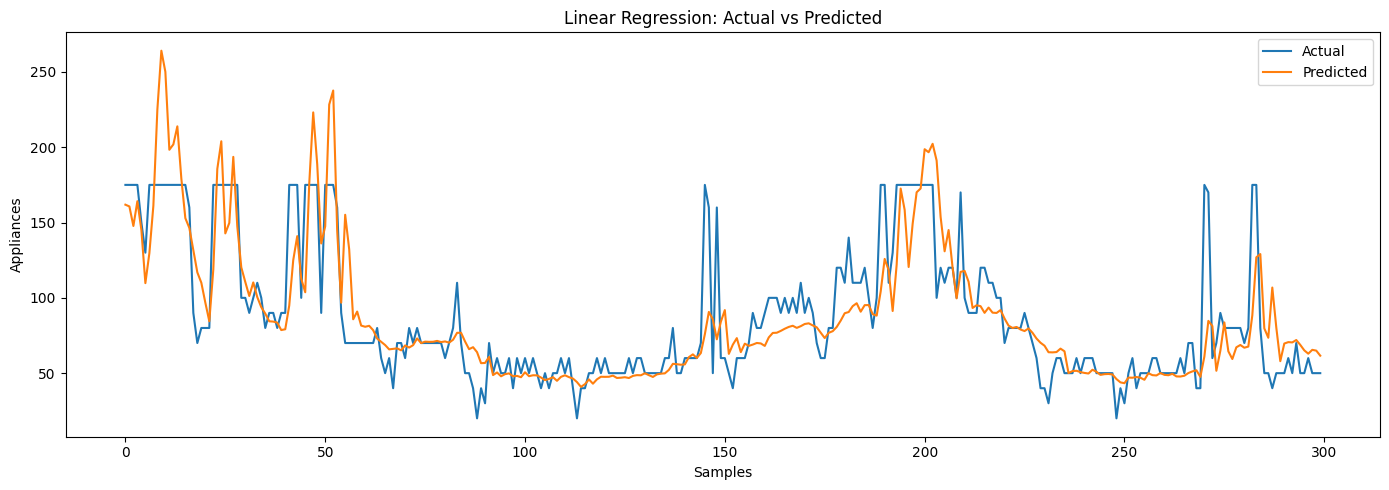

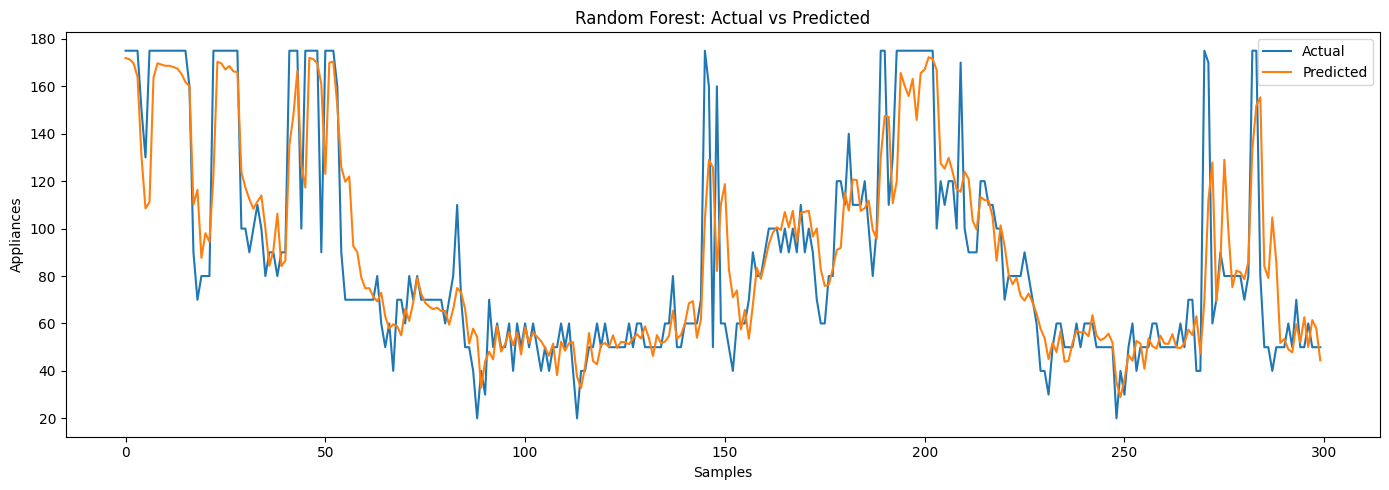

In [8]:
plot_actual_vs_predicted(
    y_true=y_test_series.to_numpy()[:300],
    y_pred=linear_predictions[:300],
    title="Linear Regression: Actual vs Predicted",
)

plot_actual_vs_predicted(
    y_true=y_test_series.to_numpy()[:300],
    y_pred=random_forest_predictions[:300],
    title="Random Forest: Actual vs Predicted",
)

### LSTM model

Creating sequences for LSTM model

In [9]:
sequence_length = 6

x_train_seq, y_train_seq = create_sequences(
    x_data=x_train_scaled,
    y_data=y_train_series.to_numpy(),
    sequence_length=sequence_length,
)

x_test_seq, y_test_seq = create_sequences(
    x_data=x_test_scaled,
    y_data=y_test_series.to_numpy(),
    sequence_length=sequence_length,
)

print("x_train_seq shape:", x_train_seq.shape)
print("y_train_seq shape:", y_train_seq.shape)
print("x_test_seq shape:", x_test_seq.shape)
print("y_test_seq shape:", y_test_seq.shape)

x_train_seq shape: (15773, 6, 40)
y_train_seq shape: (15773,)
x_test_seq shape: (3939, 6, 40)
y_test_seq shape: (3939,)


Builing the model

In [10]:
lstm_model = create_lstm_model(
    input_shape=(x_train_seq.shape[1], x_train_seq.shape[2]),
    lstm_units=64,
    dropout_rate=0.2,
)

lstm_model.summary()

c:\Users\induw\anaconda3\envs\energy_env\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        26,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,993 (113.25 KB)

 Trainable params: 28,993 (113.25 KB)

 Non-trainable params: 0 (0.00 B)

Training the model

In [11]:
early_stopping = get_early_stopping_callback(patience=5)

history = lstm_model.fit(
    x_train_seq,
    y_train_seq,
    validation_split=0.1,
    epochs=30,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1,
)

Epoch 1/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 4546.9556 - mae: 51.6432 - val_loss: 760.0458 - val_mae: 18.4386
Epoch 2/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 976.3531 - mae: 22.0749 - val_loss: 685.8833 - val_mae: 17.5134
Epoch 3/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 863.6265 - mae: 20.2039 - val_loss: 680.1651 - val_mae: 17.3162
Epoch 4/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 800.5525 - mae: 19.3997 - val_loss: 645.9337 - val_mae: 17.2440
Epoch 5/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 801.9624 - mae: 19.4364 - val_loss: 639.5413 - val_mae: 16.6157
Epoch 6/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 780.0356 - mae: 19.0014 - val_loss: 659.3233 - val_mae: 16.9920
Epoch 7/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 751.8580 - mae: 18.6979 - val_loss: 610.2337 - val_mae: 16.1573
Epoch 8/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 740.6647 - mae: 18.4890 - val_loss: 589.7952 - val_mae: 16.5041
Epoch 9

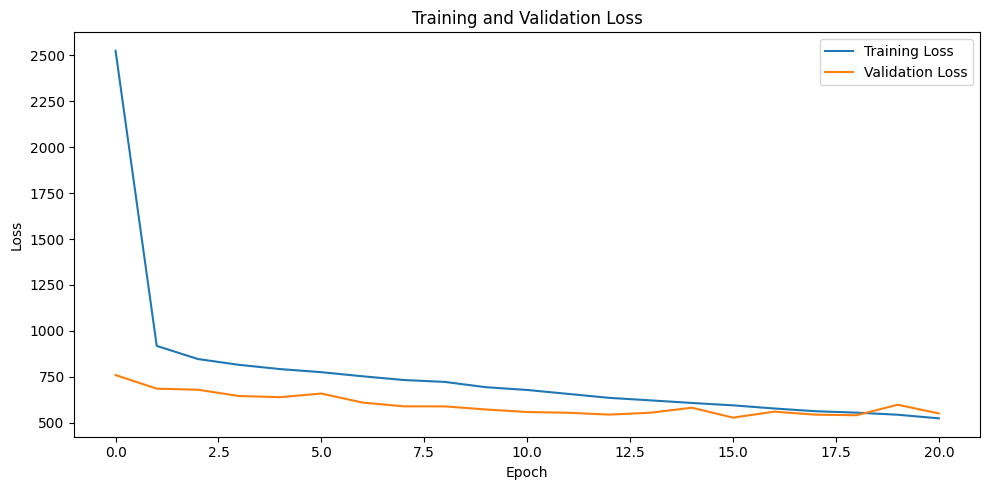

In [12]:
# plotting training history
plot_training_history(history)

Evaluating the LSTM model

In [13]:
lstm_predictions = lstm_model.predict(x_test_seq).flatten()

lstm_metrics = evaluate_regression_model(
    y_true=y_test_seq,
    y_pred=lstm_predictions,
)

lstm_metrics

124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


{'MAE': 16.5679931640625, 'RMSE': 25.496046769625018}

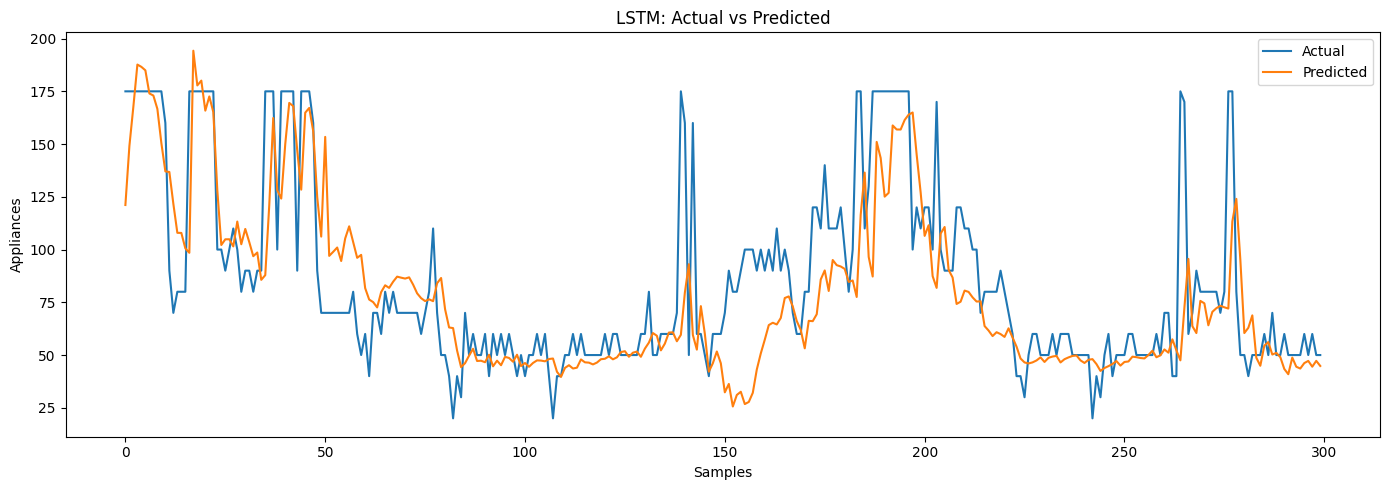

In [14]:
# plotting LSTM model predictions
plot_actual_vs_predicted(
    y_true=y_test_seq[:300],
    y_pred=lstm_predictions[:300],
    title="LSTM: Actual vs Predicted",
)

### Model Comparison 

In [15]:
comparison_df = create_model_comparison_dataframe(
    linear_metrics=linear_metrics,
    random_forest_metrics=random_forest_metrics,
    lstm_metrics=lstm_metrics,
)

comparison_df

,model,MAE,RMSE
0,Linear Regression,15.570595,22.553753
1,Random Forest,14.802757,21.402411
2,LSTM,16.567993,25.496047


In [ ]:
# saving comparison table
save_model_comparison_dataframe(
    comparison_df=comparison_df,
    file_name="model_comparison_results.csv"
)